# DEL DATO CRUDO A LA DECISIÓN


# CONTEXTO DEL DATASET

Este dataset se basa en la Encuesta de Ocupación Hotelera.

Es una elaboración propia con datos extraídos del INE, www.ine.es, en concreto:
https://www.ine.es/jaxiT3/files/t/csv_bdsc/2066.csv o bien https://www.ine.es/jaxiT3/Tabla.htm?t=2066.

La licencia es Creative Commons Reconocimiento 4.0 (CC BY 4.0).
La unidad de medida es la siguiente: 'Viajeros, Pernoctaciones, Dias, Personas, Tanto por cien, Establecimientos, Plazas y Habitaciones' (https://www.ine.es/dynt3/metadatos/es/RespuestaDatos.htm?oe=30235)

En este PDF, en las páginas 4 y 5, viene la definición de las variables (qué representa cada columna) de la tabla:
https://www.ine.es/daco/daco42/ocuphotel/meto_eoh.pdf

Último fecha de actualización: agosto de 2026 aunque los datos de enero del año 2026 y posteriores son provisionales.

Unidad de análisis (lo que representa cada fila): provincia x mes.

# 0. PREGUNTAS DE NEGOCIO


**Principal:** ¿Está la capacidad hotelera de Málaga cerca de su límite en temporada alta?

**Secundarias:**
1. ¿El empleo es estacional? (¿El empleo aumenta o disminuye con el aumento o la dismminución de la ocupación hotelera?)
2. ¿Cómo se compara Málaga con Cádiz en ocupación hotelera y personal empleado?


# 1. IMPORTAR LIBRERÍAS NECESARIAS

In [167]:
#Instalación sileciosa de missingno, sin output
%%capture
%pip install missingno

In [168]:
#RECORDATORIO: cuando se añada una nueva librería hay que ejecutar esta celda antes de ejecutar otra celda de código de esa librería.
import missingno as msno #Nulos
import pandas as pd #Manejo de datos
import numpy as np #Operaciones numéricas
import matplotlib.pyplot as plt #Visualizaciones estáticas e interactivas
import seaborn as sns #Visualizaciones (complementa a matplotlib)

from google.colab import files #Descargar el archivo

import sqlite3 #Para hacer consultas SQL

# 2. CARGAR EL DATASET

In [129]:
#Cargamos el archivo directamente desde el enlace.
df_2066 = pd.read_csv('https://www.ine.es/jaxiT3/files/t/csv_bdsc/2066.csv', sep=';')

#Si el separador del csv es ',' no haría falta especificarlo.
#En la información de los datos aparece que el separador es ';', por eso se especifica en este ejemplo.

#En caso de que la web falle, se sube el archivo y en lugar del enlace se pone el nombre del archivo. En este caso sería '2066.csv'.

In [130]:
#Nos aseguramos de que sea un dataframe
df_2066 = pd.DataFrame(df_2066)

In [131]:
#Hacemos una copia para no perder datos en el original.
df_copy2066= df_2066.copy()

# 3. EXPLORAMOS Y LIMPIAMOS EL DATASET

In [132]:
#Miramos el tamaño que tiene, es decir, cuántas filas y columnas tiene este dataset (filas, columnas).
df_copy2066.shape

(146412, 6)

In [133]:
#Exploramos el dataset viendo el principio y el final.
display(df_copy2066.head(15))
display(df_copy2066.tail(15))

,Totales Territoriales,Comunidades y Ciudades Autónomas,Provincias,Establecimientos y personal empleado (plazas),Periodo,Total
0,Total Nacional,NaN,NaN,Número de establecimientos abiertos estimados,2026M08,16.951
1,Total Nacional,NaN,NaN,Número de establecimientos abiertos estimados,2026M07,17.063
2,Total Nacional,NaN,NaN,Número de establecimientos abiertos estimados,2026M06,16.698
3,Total Nacional,NaN,NaN,Número de establecimientos abiertos estimados,2026M05,16.212
4,Total Nacional,NaN,NaN,Número de establecimientos abiertos estimados,2026M04,15.501
5,Total Nacional,NaN,NaN,Número de establecimientos abiertos estimados,2026M03,13.976
6,Total Nacional,NaN,NaN,Número de establecimientos abiertos estimados,2026M02,12.496
7,Total Nacional,NaN,NaN,Número de establecimientos abiertos estimados,2026M01,11.839
8,Total Nacional,NaN,NaN,Número de establecimientos abiertos estimados,2025M12,12.496
9,Total Nacional,NaN,NaN,Número de establecimientos abiertos estimados,2025M11,13.316


,Totales Territoriales,Comunidades y Ciudades Autónomas,Provincias,Establecimientos y personal empleado (plazas),Periodo,Total
146397,Total Nacional,19 Melilla,NaN,Personal empleado,2000M03,116
146398,Total Nacional,19 Melilla,NaN,Personal empleado,2000M02,115
146399,Total Nacional,19 Melilla,NaN,Personal empleado,2000M01,115
146400,Total Nacional,19 Melilla,NaN,Personal empleado,1999M12,116
146401,Total Nacional,19 Melilla,NaN,Personal empleado,1999M11,122
146402,Total Nacional,19 Melilla,NaN,Personal empleado,1999M10,122
146403,Total Nacional,19 Melilla,NaN,Personal empleado,1999M09,123
146404,Total Nacional,19 Melilla,NaN,Personal empleado,1999M08,89
146405,Total Nacional,19 Melilla,NaN,Personal empleado,1999M07,115
146406,Total Nacional,19 Melilla,NaN,Personal empleado,1999M06,126


In [134]:
#Para saber cuáles son las columnas y qué tipo de datos son y cuántos nulos hay.
df_copy2066.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146412 entries, 0 to 146411
Data columns (total 6 columns):
 #   Column                                         Non-Null Count   Dtype 
---  ------                                         --------------   ----- 
 0   Totales Territoriales                          146412 non-null  object
 1   Comunidades y Ciudades Autónomas               144088 non-null  object
 2   Provincias                                     99932 non-null   object
 3   Establecimientos y personal empleado (plazas)  146412 non-null  object
 4   Periodo                                        146412 non-null  object
 5   Total                                          134316 non-null  object
dtypes: object(6)
memory usage: 6.7+ MB


In [135]:
#Un resumen estadístico de las variables.
df_copy2066.describe()

,Totales Territoriales,Comunidades y Ciudades Autónomas,Provincias,Establecimientos y personal empleado (plazas),Periodo,Total
count,146412,144088,99932,146412,146412,134316
unique,1,19,43,7,332,32587
top,Total Nacional,07 Castilla y León,04 Almería,Número de establecimientos abiertos estimados,1999M01,..
freq,146412,23240,2324,20916,441,4488


In [136]:
#Buscamos duplicados
df_copy2066.duplicated().sum()

np.int64(0)

Para el INE '..' significa dato no disponible, así que esos valores en la columna 'Total' serían nulos.

In [137]:
#Reemplazamos los valores '..' como nulos para poder eliminarlos.
df_copy2066['Total'] = df_copy2066['Total'].replace('..', np.nan)

<Axes: >

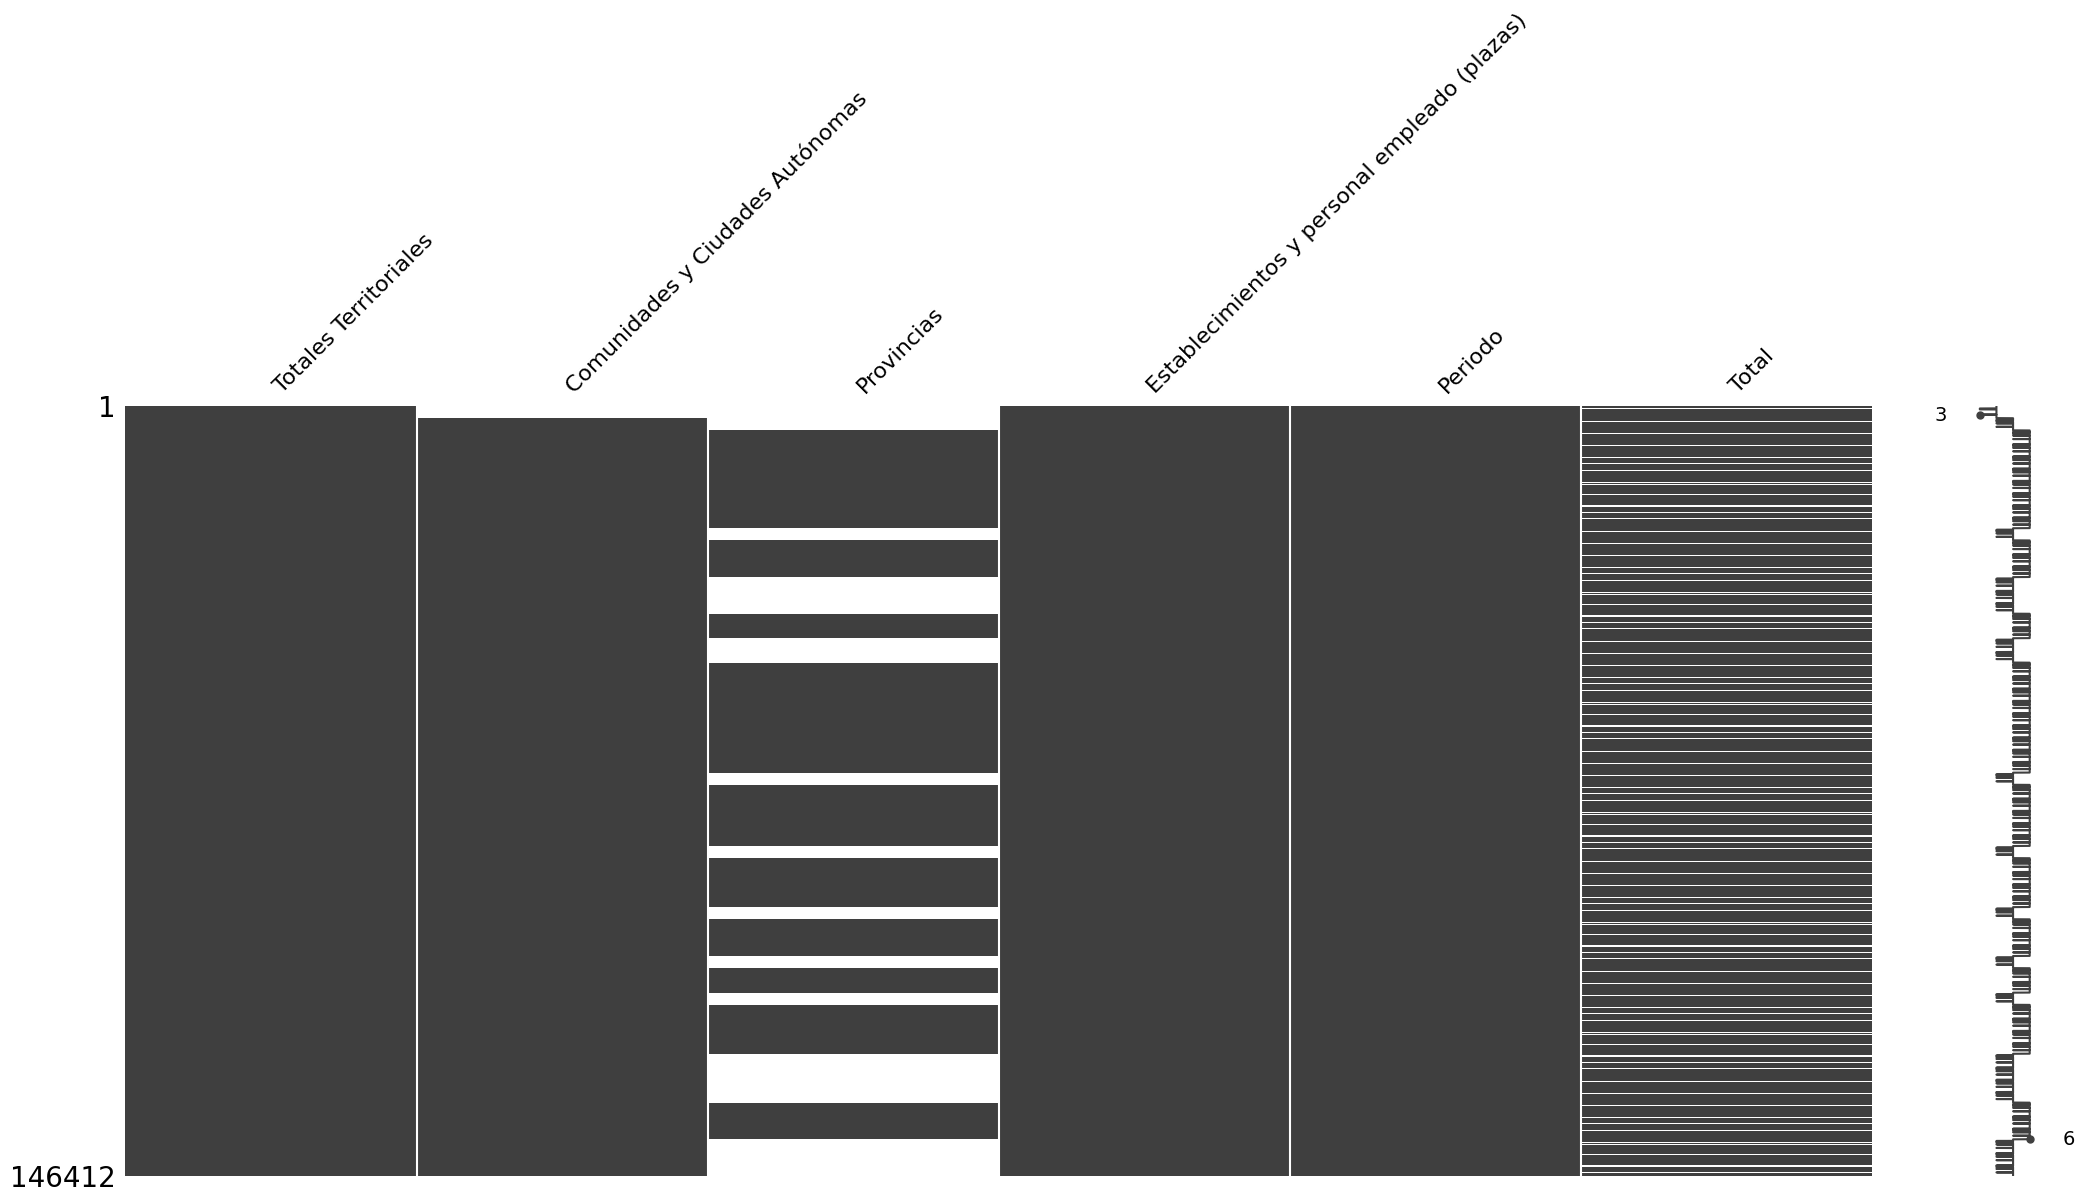

In [138]:
#Observamos los nulos con la librería misssingno.
msno.matrix(df_copy2066)



<Axes: >

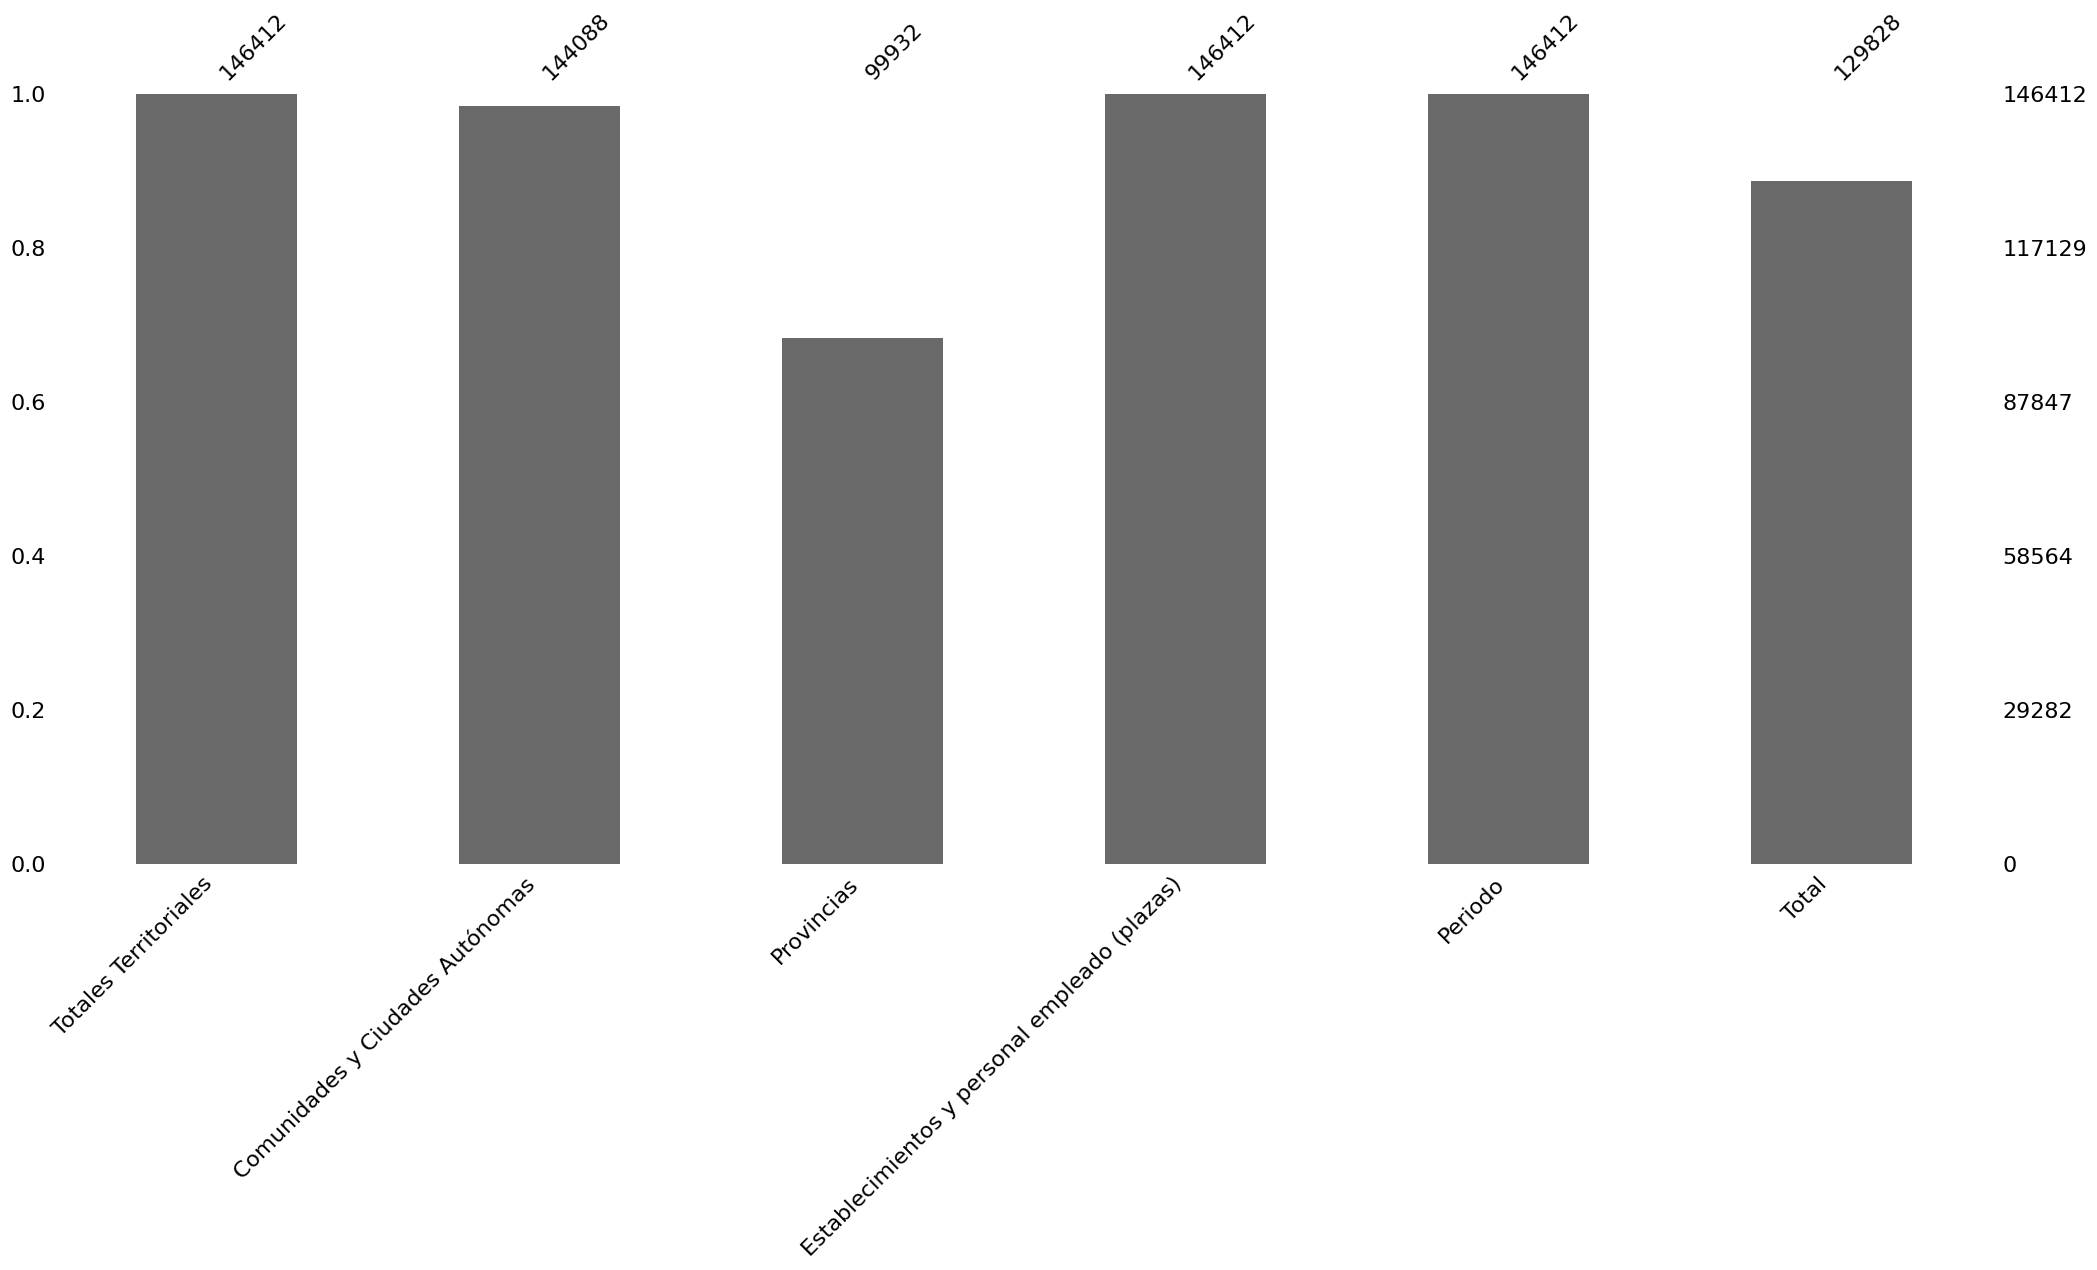

In [139]:
msno.bar(df_copy2066)

Se observa que hay muchos nulos en la columna de provincias y total y unos pocos en comunidades autónomas. Ahora buscaremos valores numéricos de esos nulos.


In [140]:
#Contamos nulos por columna, ordenados de mayor a menor
df_copy2066.isna().sum().sort_values(ascending=False)

,0
Provincias,46480
Total,16584
Comunidades y Ciudades Autónomas,2324
Totales Territoriales,0
Establecimientos y personal empleado (plazas),0
Periodo,0


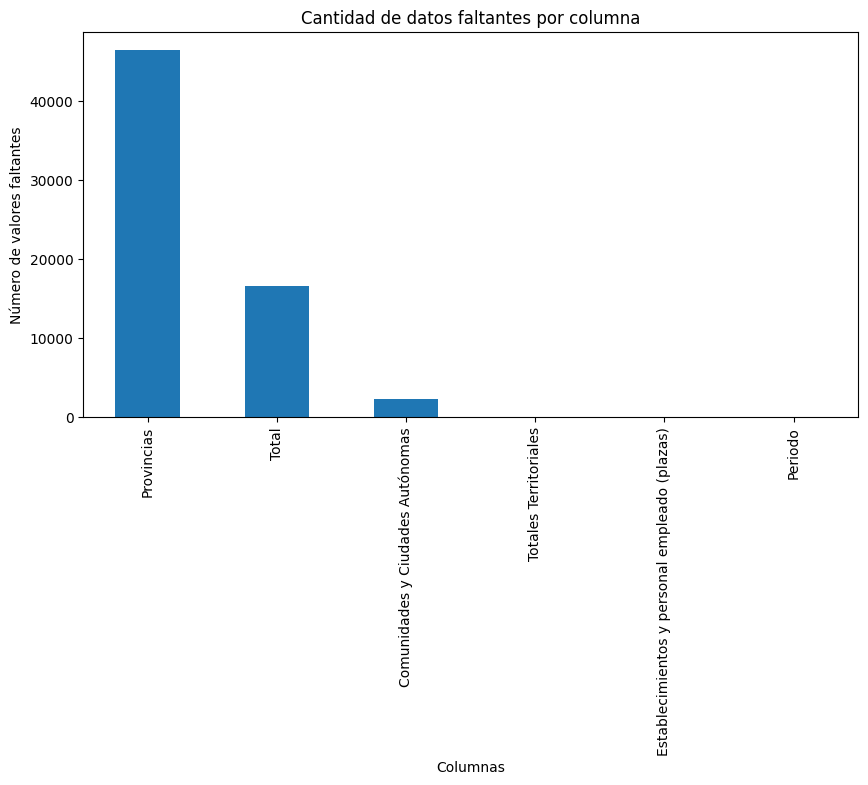

In [141]:
#La tabla con los nulos se representa en una gráfica.
missing = df_copy2066.isna().sum().sort_values(ascending=False)
#gráfica
plt.figure(figsize=(10,5))
missing.plot(kind='bar')
plt.title("Cantidad de datos faltantes por columna")
plt.ylabel("Número de valores faltantes")
plt.xlabel("Columnas")
plt.show()

Aparentemente en la de las provincias son muchos nulos, pero tenemos que buscar otras formas de confirmarlo.

Provincias                                       31.746032
Total                                            11.326940
Comunidades y Ciudades Autónomas                  1.587302
Totales Territoriales                             0.000000
Establecimientos y personal empleado (plazas)     0.000000
Periodo                                           0.000000
dtype: float64


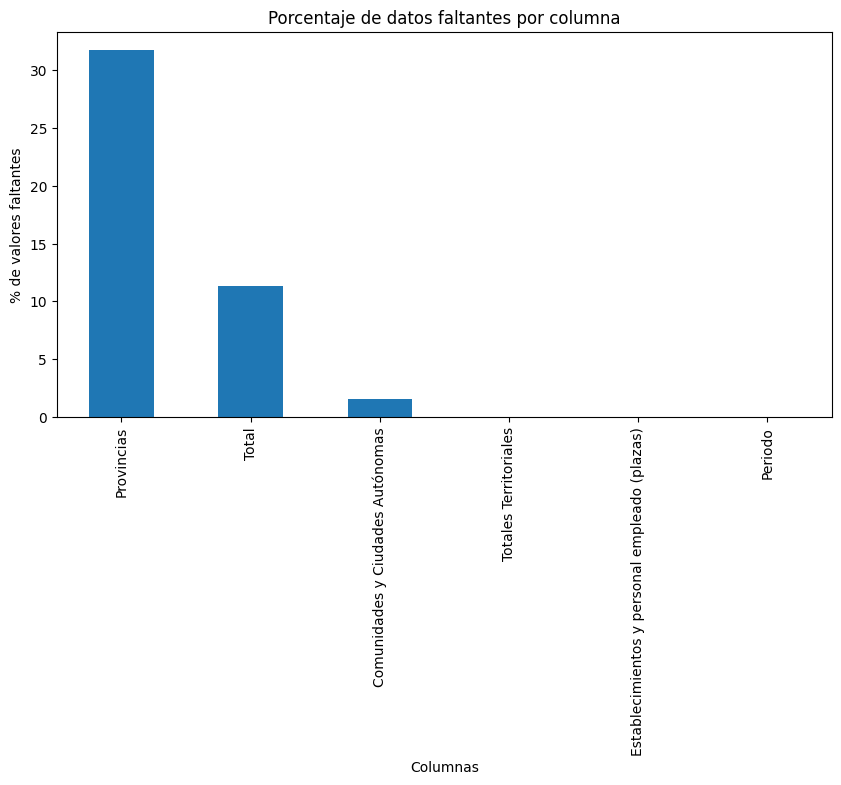

In [142]:
#Calculamos el porcentaje que representa y hacemos una gráfica
missing_pct_before = (df_copy2066.isna().mean()*100).sort_values(ascending=False)
print(missing_pct_before)
#gráfica
plt.figure(figsize=(10,5))
missing_pct_before.plot(kind='bar')
plt.title("Porcentaje de datos faltantes por columna")
plt.ylabel("% de valores faltantes")
plt.xlabel("Columnas")
plt.show()

Al calcular los nulos en forma de porcentajes podemos ver cómo la columna de las provincias tiene casi un tercio de nulos.

Como vamos a utilizar los datos donde aparezcan Málaga y Cádiz no podemos eliminar esa columna.

In [143]:
#Eliminamos las filas con nulos
df_copy2066 = df_copy2066.dropna(subset=['Comunidades y Ciudades Autónomas'])
df_copy2066 = df_copy2066.dropna(subset=['Provincias'])
df_copy2066 = df_copy2066.dropna(subset=['Total'])

Totales Territoriales                            0.0
Comunidades y Ciudades Autónomas                 0.0
Provincias                                       0.0
Establecimientos y personal empleado (plazas)    0.0
Periodo                                          0.0
Total                                            0.0
dtype: float64


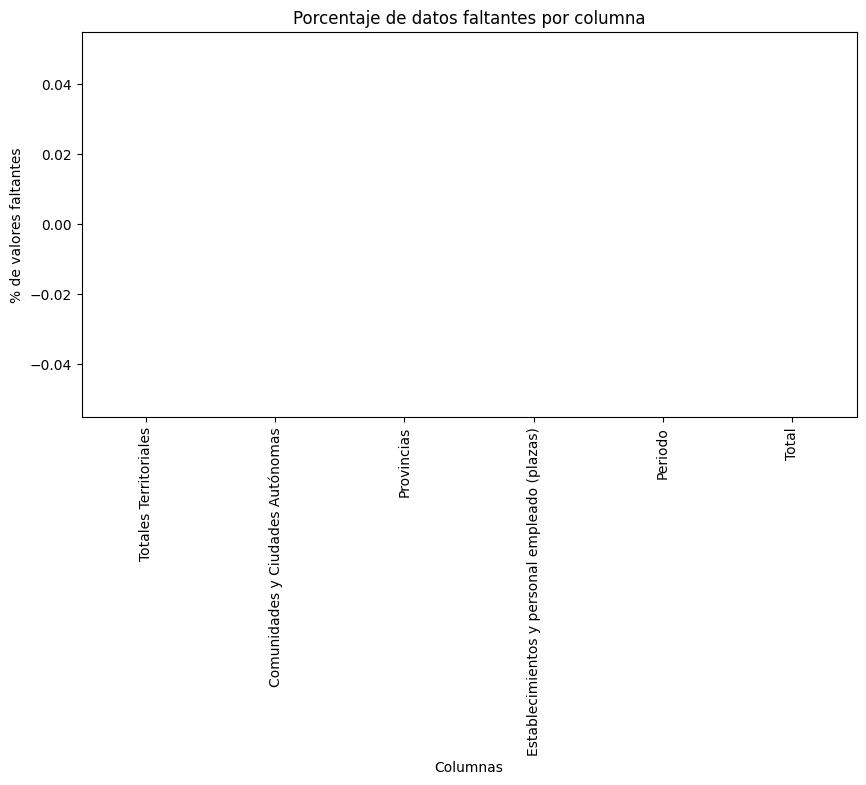

In [144]:
#Verificamos los cambios con la misma tabla de porcentajes y gráfica.

#Calculamos el porcentaje que representa de mayor a menor y hacemos una gráfica
missing_pct_after = (df_copy2066.isna().mean()*100).sort_values(ascending=False)
print(missing_pct_after)
#gráfica
plt.figure(figsize=(10,5))
missing_pct_after.plot(kind='bar')
plt.title("Porcentaje de datos faltantes por columna")
plt.ylabel("% de valores faltantes")
plt.xlabel("Columnas")
plt.show()

In [145]:
#Ahora cambiamos el tipado.
#Cambiamos el formato de fecha para tener 2 columnas donde en una aparezca el año y en la otra el mes.
fecha = pd.to_datetime(df_copy2066['Periodo'], format='%YM%m')

Mes_esp = {
    1: 'enero', 2: 'febrero', 3: 'marzo', 4: 'abril', 5: 'mayo', 6: 'junio',
    7: 'julio', 8: 'agosto', 9: 'septiembre', 10: 'octubre', 11: 'noviembre', 12: 'diciembre'
}

df_copy2066['Año'] = fecha.dt.year
df_copy2066['Mes'] = fecha.dt.month.map(Mes_esp)

In [146]:
#Lo comprobamos
df_copy2066[['Periodo', 'Año', 'Mes']].head()

,Periodo,Año,Mes
4648,2026M08,2026,agosto
4649,2026M07,2026,julio
4650,2026M06,2026,junio
4651,2026M05,2026,mayo
4652,2026M04,2026,abril


In [147]:
#Para pasar las que están de object a string.

for col in df_copy2066.columns:
  if df_copy2066[col].dtype == 'object':
    df_copy2066[col] = df_copy2066[col].astype('string')

In [148]:
#Quitamos el punto de los miles y cambiamos la coma decimal por punto
total_ = df_copy2066['Total'].str.replace('.', '', regex=False).str.replace(',', '.', regex=False)

#Luego convertimos a número y cualquier cosa que no sea número válido será NaN
df_copy2066['Total'] = pd.to_numeric(total_, errors='coerce')

In [149]:
#Ahora el tamaño del dataset es el siguiente (filas, columnas)
df_copy2066.shape


(88580, 8)

In [150]:
df_copy2066.info()

<class 'pandas.core.frame.DataFrame'>
Index: 88580 entries, 4648 to 139439
Data columns (total 8 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Totales Territoriales                          88580 non-null  string 
 1   Comunidades y Ciudades Autónomas               88580 non-null  string 
 2   Provincias                                     88580 non-null  string 
 3   Establecimientos y personal empleado (plazas)  88580 non-null  string 
 4   Periodo                                        88580 non-null  string 
 5   Total                                          88510 non-null  Float64
 6   Año                                            88580 non-null  int32  
 7   Mes                                            88580 non-null  string 
dtypes: Float64(1), int32(1), string(6)
memory usage: 5.8 MB


Al comprobarlo podemos ver que vuelven a aparecer 70 nulos más en la columna de Total, se debe al errors='coerce' para forzar el tipado.

La decisión que tomo es eliminar esas filas aunque bien se podrían mirar 1 a 1 e imputarlas.

In [151]:
df_copy2066 = df_copy2066.dropna(subset=['Total'])
#Comprobamos que se han eliminado esas filas.
df_copy2066.info()

<class 'pandas.core.frame.DataFrame'>
Index: 88510 entries, 4648 to 139439
Data columns (total 8 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Totales Territoriales                          88510 non-null  string 
 1   Comunidades y Ciudades Autónomas               88510 non-null  string 
 2   Provincias                                     88510 non-null  string 
 3   Establecimientos y personal empleado (plazas)  88510 non-null  string 
 4   Periodo                                        88510 non-null  string 
 5   Total                                          88510 non-null  Float64
 6   Año                                            88510 non-null  int32  
 7   Mes                                            88510 non-null  string 
dtypes: Float64(1), int32(1), string(6)
memory usage: 5.8 MB


Por último en la limpieza básica miramos si hay algún tipo de valor anómalo (outliers).

Lo hacemos con la variable numérica que más sentido tiene que es Total y los establecimientos para ver la estadística básica de los distintos valores únicos de esa columna.

In [152]:
#Resumen estadística descriptiva: mínimo, máximo, media, mediana
df_copy2066.groupby('Establecimientos y personal empleado (plazas)')['Total'].describe()

,count,mean,std,min,25%,50%,75%,max
Establecimientos y personal empleado (plazas),,,,,,,,
Grado de ocupación por habitaciones,14266.0,45.6991,16.864504,0.0,33.06,42.88,56.37,91.61
Grado de ocupación por plazas,14266.0,40.13759,16.267418,0.0,28.27,37.11,49.5775,91.3
Grado de ocupación por plazas en fin de semana,13234.0,47.317853,16.420528,0.0,35.86,46.25,58.89,90.55
Número de establecimientos abiertos estimados,13234.0,253.492066,177.892477,0.0,141.0,201.0,302.0,1273.0
Número de habitaciones estimadas,6010.0,11578.160899,15200.256426,0.0,3260.0,5316.0,12526.25,79478.0
Número de plazas estimadas,13234.0,23073.742633,30023.882739,0.0,6260.5,10033.0,25285.5,164987.0
Personal empleado,14266.0,3193.649516,5032.732923,0.0,669.25,1213.5,2973.75,38151.0


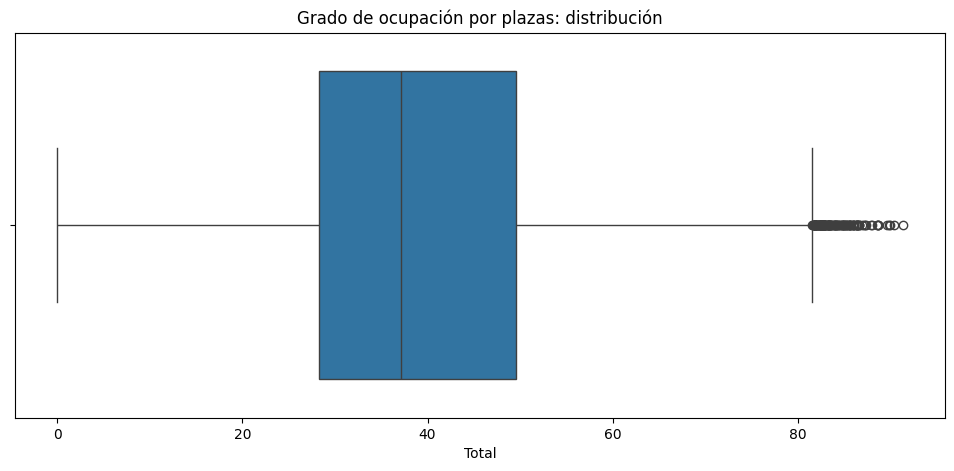

In [153]:
#Boxplot para buscar valores anómalos (outliers)
plt.figure(figsize=(12,5))
sns.boxplot(data=df_copy2066[df_copy2066['Establecimientos y personal empleado (plazas)'] == 'Grado de ocupación por plazas'], x='Total')
plt.title('Grado de ocupación por plazas: distribución')
plt.show()

Hay valores anómalos por encima del 80%, pero pueden ser picos en el grado de ocupación.

No se eliminan porque tiene sentido para el contexto y no son superiores al 100% ni inferiores al 0%.

#4. EXPORTAMOS EL CSV YA LIMPIO

In [154]:
#Para que aparezca a la izquierda
df_copy2066.to_csv('2066_limpio.csv', index=False)

#Para que se descargue automáticamente
files.download("2066_limpio.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#5. CONSULTAS SQL

Consulta 1: ¿Dónde se sitúa Málaga en ocupación hotelera frente al resto de provincias?

In [155]:
#Abrimos una base de datos llamada '2066.db'
consultas = sqlite3.connect('2066.db')
#La tabla limpia la llamamos 'tabla_2066_limpia', index = False no guarda el índice de pandas como una columna más.
#Reemplaza la tabla si ya existe si se ejecuta una segunda vez para que no dé error.
df_copy2066.to_sql('tabla_2066_limpia', consultas, index=False, if_exists='replace')
#Consulta 1
pd.read_sql("""
SELECT "Provincias" AS provincia, AVG("Total") AS ocupacion_media
FROM tabla_2066_limpia
WHERE "Establecimientos y personal empleado (plazas)" = 'Grado de ocupación por plazas'
GROUP BY provincia
ORDER BY ocupacion_media DESC
""", consultas)

,provincia,ocupacion_media
0,"35 Palmas, Las",68.509759
1,38 Santa Cruz de Tenerife,68.142771
2,03 Alicante/Alacant,61.770663
3,08 Barcelona,57.661777
4,29 Málaga,56.545602
5,20 Gipuzkoa,50.958223
6,41 Sevilla,50.011175
7,46 Valencia/València,47.999940
8,48 Bizkaia,47.572952
9,43 Tarragona,47.413193


Agrupa por provincias la ocupación media por plazas y ordena de mayor a menor. Málaga aparece 5ª con una media del 56,5 %, por encima de Cádiz (44,9 %, puesto 13).

Consulta 2: ¿En qué meses tiene Málaga la ocupación más alta?

In [156]:
#Consulta 2
pd.read_sql("""
SELECT "Mes", ROUND(AVG("Total"), 1) AS ocupacion_media
FROM tabla_2066_limpia
WHERE "Provincias" LIKE '%Málaga%'
  AND "Establecimientos y personal empleado (plazas)" = 'Grado de ocupación por plazas'
  AND "Año" BETWEEN 2022 AND 2025
GROUP BY "Mes"
HAVING AVG("Total") > 65
ORDER BY ocupacion_media DESC
LIMIT 6
""", consultas)

,Mes,ocupacion_media
0,agosto,79.5
1,julio,74.2
2,septiembre,70.3
3,junio,69.2
4,mayo,66.5
5,octubre,66.4


Calcula la ocupación media por mes en Málaga (2022-2025) y se queda con los meses que superan el 65 %. Agosto lidera con un 79,5 %, seguido de julio (74,2 %), septiembre (70,3 %) y junio (69,2 %); mayo y octubre quedan justo por encima del umbral (66,5 % y 66,4 %). La temporada alta se concentra en verano.

Consulta 3: ¿Cómo se compara Málaga con Cádiz en ocupación y personal empleado?

In [157]:
#Consulta 3
pd.read_sql("""
SELECT "Provincias" AS provincia,
       "Establecimientos y personal empleado (plazas)" AS metrica,
       ROUND(AVG("Total"), 1) AS media
FROM tabla_2066_limpia
WHERE ("Provincias" LIKE '%Málaga%' OR "Provincias" LIKE '%Cádiz%')
  AND "Establecimientos y personal empleado (plazas)" IN ('Grado de ocupación por plazas', 'Personal empleado')
  AND "Año" BETWEEN 2022 AND 2025
GROUP BY "Provincias", "Establecimientos y personal empleado (plazas)"
""", consultas)

,provincia,metrica,media
0,11 Cádiz,Grado de ocupación por plazas,50.4
1,11 Cádiz,Personal empleado,6719.6
2,29 Málaga,Grado de ocupación por plazas,60.5
3,29 Málaga,Personal empleado,15226.3


Compara las medias de ambas provincias entre 2022-2025. Málaga tiene una ocupación media del 60,5 % frente al 50,4 % de Cádiz, y una media de 15.226 personas empleadas frente a 6.720.

Consulta 4: ¿El empleo del sector aumenta en temporada alta, cuando sube la ocupación?

In [158]:
#Creamos tabla auxiliar para hacer la consulta con join donde ponemos los meses de verano como alta temporada.
temporadas = pd.DataFrame({
    'Mes': ['enero','febrero','marzo','abril','mayo','junio','julio','agosto',
            'septiembre','octubre','noviembre','diciembre'],
    'temporada': ['baja','baja','baja','baja','baja','alta','alta','alta',
                  'alta','baja','baja','baja']
})
temporadas.to_sql('temporadas', consultas, index=False, if_exists='replace')

#Consulta 4
pd.read_sql("""
SELECT t.temporada,
       ROUND(AVG(CASE WHEN c."Establecimientos y personal empleado (plazas)" = 'Grado de ocupación por plazas' THEN c."Total" END), 1) AS ocupacion_media,
       ROUND(AVG(CASE WHEN c."Establecimientos y personal empleado (plazas)" = 'Personal empleado' THEN c."Total" END), 0) AS personal_medio
FROM tabla_2066_limpia c
JOIN temporadas t ON c."Mes" = t."Mes"
WHERE c."Provincias" LIKE '%Málaga%' AND c."Año" BETWEEN 2022 AND 2025
GROUP BY t.temporada
""", consultas)

,temporada,ocupacion_media,personal_medio
0,alta,73.3,19024.0
1,baja,54.1,13328.0


En temporada alta Málaga tiene un 73,3 % de ocupación media y 19.024 personas empleadas, en temporada baja, un 54,1 % y 13.328. El empleo es un 43 % mayor en los meses de alta ocupación, lo que indica un patrón estacional. Si supiéramos más sobre el tipo de contrato o salario podríamos decir con datos si el tipo de empleo que proporciona el turismo tiene buenas condiciones o es más bien precario.

En las consultas donde aparezca la media habría que tener en cuenta también la desviación típica (el intervalo donde estaría la media), para poder comparar con más seguridad y dar unas conclusiones más sólidas u otras medidas como la mediana o la moda.

#6. EDA (Análisis Exploratorio de Datos)

Creamos diversos filtros para visualizar distintas gráficas.

In [159]:
#Creamos una nueva columna de fecha con el formato de añoMmes, por ejemplo, 2020M01 significaría enero de 2020.
df_copy2066['Fecha'] = pd.to_datetime(df_copy2066['Periodo'], format='%YM%m')
#Extraemos el mes de esa columna
df_copy2066['MesNum'] = df_copy2066['Fecha'].dt.month

#Filtramos por Málaga y Cádiz y por Grado de ocupación por plazas
metrica = 'Establecimientos y personal empleado (plazas)'
mal_cad = df_copy2066['Provincias'].str.contains('Málaga|Cádiz')

ocup = df_copy2066[(df_copy2066[metrica] == 'Grado de ocupación por plazas') & mal_cad]
personal = df_copy2066[(df_copy2066[metrica] == 'Personal empleado') & mal_cad]

#Se filtra la ocupación hotelera entre los años 2022-2025 y solo para Málaga
ocup_rec = ocup[ocup['Año'].between(2022, 2025)]
ocup_mal = ocup_rec[ocup_rec['Provincias'].str.contains('Málaga')]
personal_mal = personal[personal['Año'].between(2022, 2025) & personal['Provincias'].str.contains('Málaga')]

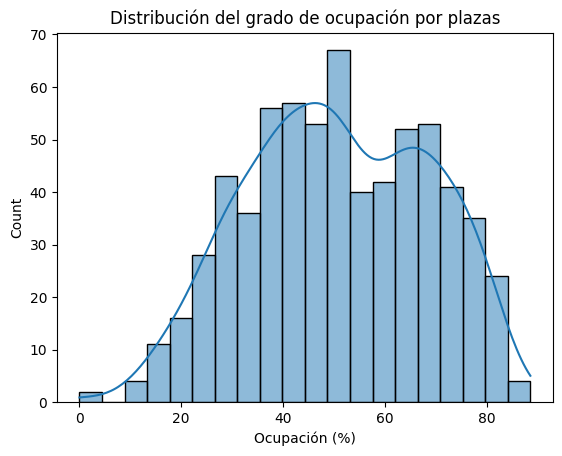

In [160]:
#Se hace un histograma con la distribución del grado de ocupación por plazas.
sns.histplot(data=ocup, x='Total', kde=True, bins=20)
plt.title('Distribución del grado de ocupación por plazas')
plt.xlabel('Ocupación (%)')
plt.show()

De aquí podemos observar que la tendencia de la curva es a la derecha, es decir, tiende hacia un porcentaje de ocupación mayor. Se repite más veces una icupación del 70% que una del 20%.

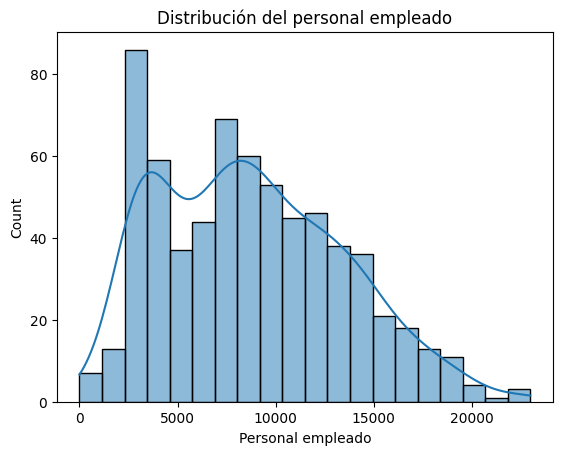

In [161]:
#Se hace un histograma con la distribución del personal empleado.
sns.histplot(data=personal, x='Total', kde=True, bins=20)
plt.title('Distribución del personal empleado')
plt.xlabel('Personal empleado')
plt.show()


De aquí sacamos la conclusión opuesta, la curva tiende más hacia la derecha. Tiende a haber más personal en torno a las 5000 personas que a las 15000.

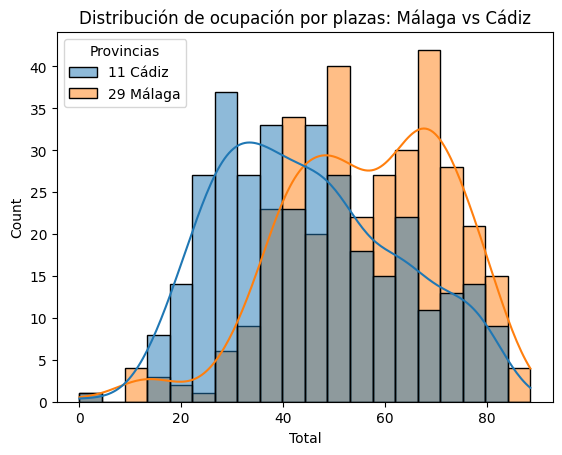

In [162]:
#Comparamos la ocupación de plazas entre las dos provincias
sns.histplot(data=ocup, x='Total', hue='Provincias', kde=True, bins=20, alpha=0.5)
plt.title('Distribución de ocupación por plazas: Málaga vs Cádiz')
plt.xlabel('Total')
plt.show()


Se observa que en Cádiz la ocupación es menor a la de Málaga.

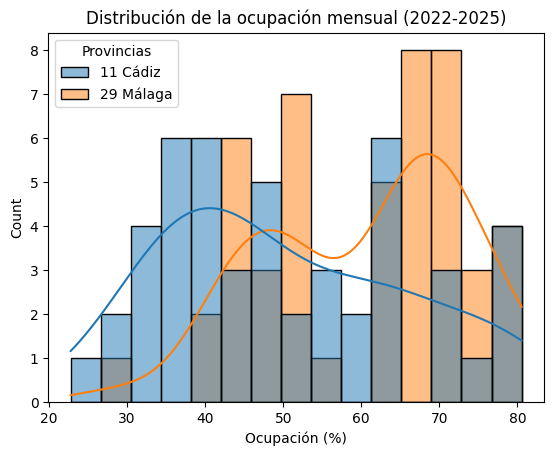

In [163]:
#Histograma con la distribución de la ocupación mensual entre los años 2022 y 2025.
sns.histplot(data=ocup_rec, x='Total', hue='Provincias', kde=True, bins=15)
plt.title('Distribución de la ocupación mensual (2022-2025)')
plt.xlabel('Ocupación (%)')
plt.show()

En este histograma podemos observar que la mayor frecuencia (el % que más se repite) de ocupación hotelera en Málaga es en torno al 70% y en Cádiz en torno al 40%. Es decir, muestra que la ocupación hotelera es más alta en Málaga que en Cádiz, durante esos años.

#7. VISUALIZACIONES

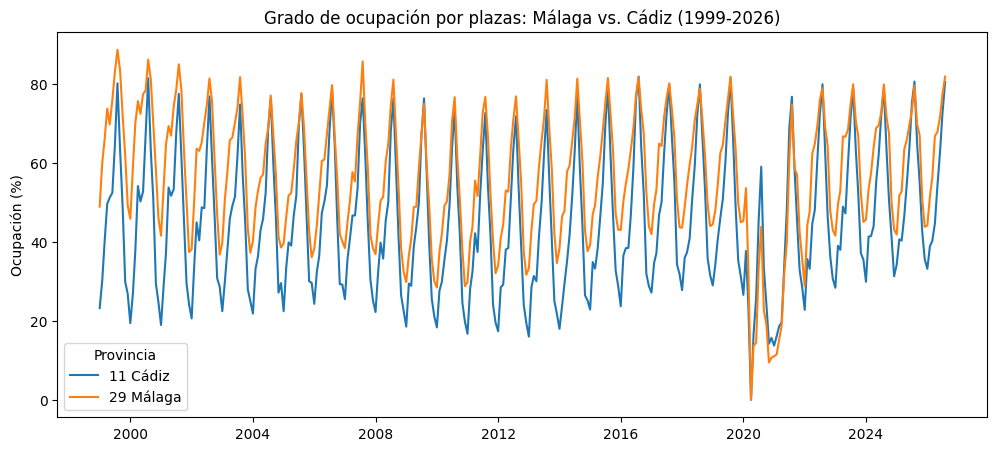

In [164]:
#Visualización 1
plt.figure(figsize=(12, 5))
sns.lineplot(data=ocup, x='Fecha', y='Total', hue='Provincias')
plt.title('Grado de ocupación por plazas: Málaga vs. Cádiz (1999-2026)')
plt.xlabel('')
plt.ylabel('Ocupación (%)')
plt.legend(title='Provincia')
plt.show()

Es interesante ver cómo cae el pico en Málaga en 2020 hasta casi el 0% de ocupación hotelera, mientras que en Cádiz bajó pero no lo hizo con la misma intensidad. Sería interesante poder investigar por qué sucede ese mínimo tan intenso.

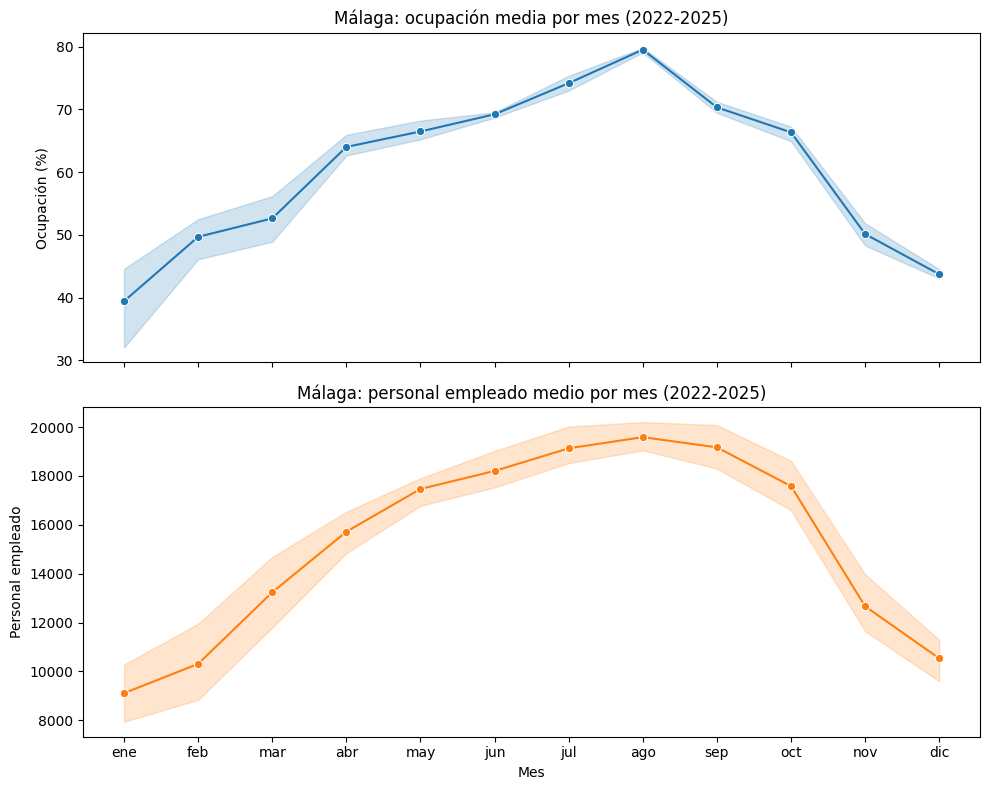

In [165]:
#Visualización 2
fig, ejes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

sns.lineplot(data=ocup_mal, x='MesNum', y='Total', ax=ejes[0], marker='o')
ejes[0].set_title('Málaga: ocupación media por mes (2022-2025)')
ejes[0].set_ylabel('Ocupación (%)')

sns.lineplot(data=personal_mal, x='MesNum', y='Total', ax=ejes[1], marker='o', color='tab:orange')
ejes[1].set_title('Málaga: personal empleado medio por mes (2022-2025)')
ejes[1].set_ylabel('Personal empleado')
ejes[1].set_xlabel('Mes')
ejes[1].set_xticks(range(1, 13))
ejes[1].set_xticklabels(['ene','feb','mar','abr','may','jun','jul','ago','sep','oct','nov','dic'])

plt.tight_layout()
plt.show()

En estas gráficas se observa la misma tendencia, es decir, el mismo patrón, pero se ha hecho en gráficas distintas porque tienen el eje Y con distintas unidades.

Estas gráficas muestran que en los meses de verano aumenta la ocupación y el personal empleado. Tiene sentido con todo lo que hemos ido viendo.

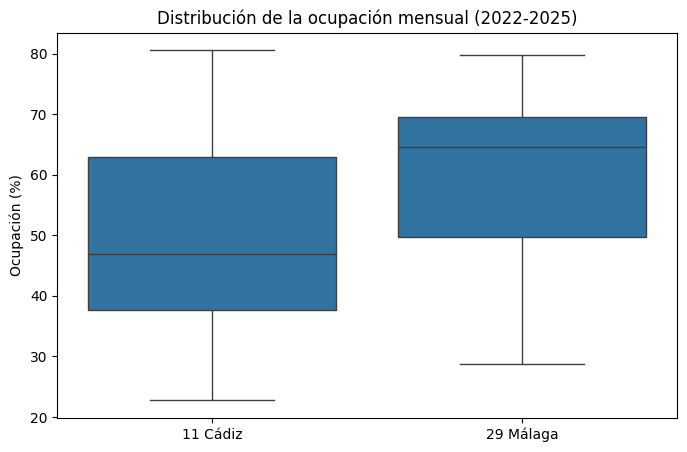

In [166]:
#Visualización 3
plt.figure(figsize=(8, 5))
sns.boxplot(data=ocup_rec, x='Provincias', y='Total')
plt.title('Distribución de la ocupación mensual (2022-2025)')
plt.xlabel('')
plt.ylabel('Ocupación (%)')
plt.show()

Este diagrama de cajas y bigotes muestra la distribución de la visualización 1 desde otra perspectiva, la mediana en Málaga está casi al 70% y en Cádiz casi al 50%. El mínimo de ocupación en Cádiz es menor al de Málaga, pero el pico máximo es parecido. Todo esto sigue teniendo sentido con lo que se ha visto.

No se elige una gráfica circular porque con este dataset no tiene sentido. Se usa cuando hay pocas opciones y juntas suman el 100%.
Tendría sentido usarlo si por ejemplo el dataset hablara de tipos de alojamientos en Málaga. Podría ser en ese caso una buena idea para ver qué tipo de alojamiento es el más común.


Se elige el de ocupación media por mes y empleados medios por mes para ver que están relacionados, a medida que sube la ocupación hotelera aumentan los empleos.

#Conclusiones:


**¿Está Málaga al límite?**

No se puede saber con estos datos solamente, habría que investigarlo en más profundidad. Lo que sí se sabe es que la ocupación media es relativamente alta, sobretodo si la comparamos con su provincia vecina, Cádiz.

Ambas llegan a unos máximos de ocupación parecidos, mientras que el mínimo de ocupación en Málaga (se observa tanto en la visualización 1 como la 3) no baja tanto como en Cádiz, mientras que la mediana, es decir, el 50%, en Málaga siempre está más alto.

También podemos concluir con que quizás no esté al límite, pero sí tiene una fuerte exigencia hotelera, especialmente en verano, pero que se mantiene en el tiempo. Esto podría dar lugar a otros posibles problemas para los que habría que investigar, como por ejemplo el transporte, si este en esos meses de alta ocupación hotelera están al límite o no.


**¿El empleo es estacional? (¿El empleo aumenta o disminuye con el aumento o la dismminución de la ocupación hotelera?)**

Sí, lo es. Es especialmente alto en verano, fuera de estos meses llega a disminuir casi un 50%. Esto nos puede llevar a otras preguntas como la calidad del empleo en los meses de alta y baja ocupación hotelera, por ejemplo.

No se puede afirmar que esta estacionalidad afecte negativamente a la calidad del empleo (haciendo que este sea precario) porque no tenemos suficientes datos, pero sí se puede afirmar que el hecho de que el empleo sea estacional hace que no haya estabilidad en el empleo, lo cual sí es algo negativo a rasgos generales.


**¿Cómo se compara Málaga con Cádiz en ocupación hotelera y personal empleado?**

Málaga tiene de media una mayor ocupación hotelera aunque el máximo de ocupación sea relativamente similar. Sin embargo, en los meses de menor ocupación hotelera la caída es mayor en Cádiz, es decir, la ocupación hotelera se mantiene más estable en Málaga, estando normalmente alrededor del 50%.

# Recomendaciones

Estas recomendaciones serían para la diputación de Málaga.

Sería recomendable estudiar si la ocupación hotelera en general tan alta a lo largo de los años puede tener consecuencias para la calidad de vida de los ciudadanos. También podría investigar si es algo que pase con otro tipo de trabajos no turísticos y decidir si es beneficioso fomentar otras formas de empleo que no se basen en algo temporal.

Sería recomendable estudiar cómo afecta esta alta ocupación a los habitantes de Málaga. En precios del alquiler, en el transporte público, en calidad del empleo, en calidad de vida, etc.

#Reflexiones y limitaciones

Hay que tener en cuenta que la ocupación hotelera no es la única que hay actualmente en Málaga. También existen otras opciones como apartamentos turísticos o AirB&B.

Tampoco hay datos en este dataset sobre otro tipo de empleos, podríamos compararlo con otras profesiones que no tengan esa estacionalidad o con otros que sí la tengan, para ver si hay otros factores que afecten más a la calidad del empleo y la vida.

También hay que tener en cuenta los propios sesgos, por ejemplo, si se está en contra o a favor del turismo masivo, se harán unas preguntas de negocios u otras, no es lo mismo preguntar si Málaga está al límite o si Málaga admite más turismo. Para ambas preguntas la respuesta de que Málaga durante la temporada alta, en verano, es cercana al 80% puede tener interpretaciones distintas.


No es posible librarse de los sesgos, pero es importante hacer un esfuerzo por no llevar los datos a las conclusiones que queremos que tengan y no usar la estadística de forma intencional o no para que nos favorezcan omitiendo información (como puede ser omitir la desviación típica o la mediana cuando hablamos de media).

